## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
fatal: unable to access 'https://github.com/Lv1g1/RecSys-Challenge-2025.git/': Could not resolve host: github.com


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import os, gc
import joblib
import pandas as pd
import numpy as np
from xgboost import XGBRanker, plot_importance

from Challenge.paths import XGBOOST_DATAFRAMES, XGBOOST_MODELS, generate_submission
from Challenge.XGBoostReranker import XGBoostRerankerRecommender, ProgressCallback

Running on local — storage at: /home/luigi/RecSys


## **Load Data**

In [4]:
# Concatenate all folds
all_dfs = []
for fold_idx in range(10):
    file_path = os.path.join(XGBOOST_DATAFRAMES, "OOF_folds", f"prediction_train_OOF_fold{fold_idx}.parquet")

    df_fold = pd.read_parquet(
        file_path,
        engine='fastparquet',
    )

    print(f"Loaded successfully from: {file_path}")
    all_dfs.append(df_fold)

X_train_full = pd.concat(all_dfs, ignore_index=True)

# Free memory
del all_dfs
gc.collect()

# Sort by UserID for faster access during training
X_train_full.sort_values(by='UserID', inplace=True)

# Categorical handling
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    if col in X_train_full.columns:
        X_train_full[col] = X_train_full[col].astype('category')

print(f"Final OOF Dataset Shape: {X_train_full.shape}")
print(f"Memory Usage: {X_train_full.memory_usage().sum() / 1e6:.2f} MB")

assert X_train_full['UserID'].is_monotonic_increasing, "Training set is not sorted by UserID!"

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold0.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold1.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold2.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold3.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold4.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold5.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold6.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold7.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/

In [5]:
X_train_full.columns.tolist()

['UserID',
 'ItemID',
 'top_10',
 'top_20',
 'top_30',
 'top_40',
 'top_50',
 'Label',
 'EASE_R_Score',
 'EASE_R_RankPosition',
 'EASE_R_Recommended',
 'SLIMElasticNet_Score',
 'SLIMElasticNet_RankPosition',
 'SLIMElasticNet_Recommended',
 'MultVAE_Score',
 'MultVAE_RankPosition',
 'MultVAE_Recommended',
 'MatrixFactorization_WARP_Score',
 'MatrixFactorization_WARP_RankPosition',
 'MatrixFactorization_WARP_Recommended',
 'MatrixFactorization_BPR_Score',
 'MatrixFactorization_BPR_RankPosition',
 'MatrixFactorization_BPR_Recommended',
 'NMF_Score',
 'NMF_RankPosition',
 'NMF_Recommended',
 'TopPop_Score',
 'TopPop_RankPosition',
 'TopPop_Recommended',
 'ItemKNN_cosine_Score',
 'ItemKNN_cosine_RankPosition',
 'ItemKNN_cosine_Recommended',
 'ItemKNN_jaccard_Score',
 'ItemKNN_jaccard_RankPosition',
 'ItemKNN_jaccard_Recommended',
 'ItemKNN_asymmetric_Score',
 'ItemKNN_asymmetric_RankPosition',
 'ItemKNN_asymmetric_Recommended',
 'ItemKNN_tversky_Score',
 'ItemKNN_tversky_RankPosition',
 'It

## **Train**

In [6]:
# Groups
groups = X_train_full.groupby("UserID").size().values

# Target
y_train = X_train_full["Label"]

# Drop metadata to create Feature Matrix
X_train_full = X_train_full.drop(columns=["Label", "UserID", "ItemID"], errors='ignore')

assert groups.sum() == X_train_full.shape[0], "Group sum mismatch!"

In [7]:
params = {
    'n_estimators': 800,
    'objective': 'rank:ndcg',
    'grow_policy': 'depthwise',
    'learning_rate': 0.01069123309545738,
    'colsample_bytree': 0.6,
    'max_depth': 12,
    'min_child_weight': 100,
    'subsample': 0.85,
    'reg_alpha': 2.0,
    'reg_lambda': 1.47
}

for s in [0xbeef, 0xbabe, 0xc0ffe, 0xface, 42]:
    model_save_path = os.path.join(XGBOOST_MODELS, f"xgboost_blind_crazy_model_seed_{s}.joblib")
    
    print(f"\n=== Training seed: {s} ===")
    
    if os.path.exists(model_save_path):
        print("  model already trained. Skipping...")
        continue

    if s == 0xbabe or s == 0xface:
        params['n_estimators'] = 850
    else:
        params['n_estimators'] = 800

    XGB_model = XGBRanker(
        **params,
        enable_categorical=True,
        tree_method="hist",
        n_jobs=-1,
        random_state=s,
        callbacks=[
            ProgressCallback(total_trees=params['n_estimators'], period=10)
        ]
    )

    XGB_model.fit(
        X_train_full, y_train, group=groups,
        verbose=False
    )

    # Store model
    joblib.dump(XGB_model, model_save_path)
    print(f"Model for seed {s} saved to {model_save_path}")


=== Training seed: 48879 ===
[Training] Tree 10/800
[Training] Tree 20/800
[Training] Tree 30/800
[Training] Tree 40/800
[Training] Tree 50/800
[Training] Tree 60/800
[Training] Tree 70/800
[Training] Tree 80/800
[Training] Tree 90/800
[Training] Tree 100/800
[Training] Tree 110/800
[Training] Tree 120/800
[Training] Tree 130/800
[Training] Tree 140/800
[Training] Tree 150/800
[Training] Tree 160/800
[Training] Tree 170/800
[Training] Tree 180/800
[Training] Tree 190/800
[Training] Tree 200/800
[Training] Tree 210/800
[Training] Tree 220/800
[Training] Tree 230/800
[Training] Tree 240/800
[Training] Tree 250/800
[Training] Tree 260/800
[Training] Tree 270/800
[Training] Tree 280/800
[Training] Tree 290/800
[Training] Tree 300/800
[Training] Tree 310/800
[Training] Tree 320/800
[Training] Tree 330/800
[Training] Tree 340/800
[Training] Tree 350/800
[Training] Tree 360/800
[Training] Tree 370/800
[Training] Tree 380/800
[Training] Tree 390/800
[Training] Tree 400/800
[Training] Tree 410

KeyboardInterrupt: 

## **Generate submission**

In [4]:
cols = ['UserID',
 'ItemID',
 'top_10',
 'top_20',
 'top_30',
 'top_40',
 'top_50',
 # 'Label',
 'EASE_R_Score',
 'EASE_R_RankPosition',
 'EASE_R_Recommended',
 'SLIMElasticNet_Score',
 'SLIMElasticNet_RankPosition',
 'SLIMElasticNet_Recommended',
 'MultVAE_Score',
 'MultVAE_RankPosition',
 'MultVAE_Recommended',
 'MatrixFactorization_WARP_Score',
 'MatrixFactorization_WARP_RankPosition',
 'MatrixFactorization_WARP_Recommended',
 'MatrixFactorization_BPR_Score',
 'MatrixFactorization_BPR_RankPosition',
 'MatrixFactorization_BPR_Recommended',
 'NMF_Score',
 'NMF_RankPosition',
 'NMF_Recommended',
 'TopPop_Score',
 'TopPop_RankPosition',
 'TopPop_Recommended',
 'ItemKNN_cosine_Score',
 'ItemKNN_cosine_RankPosition',
 'ItemKNN_cosine_Recommended',
 'ItemKNN_jaccard_Score',
 'ItemKNN_jaccard_RankPosition',
 'ItemKNN_jaccard_Recommended',
 'ItemKNN_asymmetric_Score',
 'ItemKNN_asymmetric_RankPosition',
 'ItemKNN_asymmetric_Recommended',
 'ItemKNN_tversky_Score',
 'ItemKNN_tversky_RankPosition',
 'ItemKNN_tversky_Recommended',
 'ItemKNN_dice_Score',
 'ItemKNN_dice_RankPosition',
 'ItemKNN_dice_Recommended',
 'UserKNN_cosine_Score',
 'UserKNN_cosine_RankPosition',
 'UserKNN_cosine_Recommended',
 'UserKNN_jaccard_Score',
 'UserKNN_jaccard_RankPosition',
 'UserKNN_jaccard_Recommended',
 'UserKNN_asymmetric_Score',
 'UserKNN_asymmetric_RankPosition',
 'UserKNN_asymmetric_Recommended',
 'UserKNN_tversky_Score',
 'UserKNN_tversky_RankPosition',
 'UserKNN_tversky_Recommended',
 'UserKNN_dice_Score',
 'UserKNN_dice_RankPosition',
 'UserKNN_dice_Recommended',
 'P3alpha_Score',
 'P3alpha_RankPosition',
 'P3alpha_Recommended',
 'RP3beta_Score',
 'RP3beta_RankPosition',
 'RP3beta_Recommended',
 'IALS_Score',
 'IALS_RankPosition',
 'IALS_Recommended',
 'SLIMElasticNet_MaxSim',
 'SLIMElasticNet_MeanSim',
 'SLIMElasticNet_StdSim',
 'SLIMElasticNet_MatchCount',
 'ItemKNN_tversky_MaxSim',
 'ItemKNN_tversky_MeanSim',
 'ItemKNN_tversky_StdSim',
 'ItemKNN_tversky_MatchCount',
 'RP3beta_MaxSim',
 'RP3beta_MeanSim',
 'RP3beta_StdSim',
 'RP3beta_MatchCount',
 'User_Cluster',
 'Item_Cluster',
 'Cluster_Interaction',
 'User_Cluster_Dist',
 'Item_Cluster_Dist',
 'User_to_ItemCluster_Dist',
 'User_Vector_Norm',
 'Item_Vector_Norm',
 'User_PCA_0',
 'Item_PCA_0',
 'User_PCA_1',
 'Item_PCA_1',
 'User_PCA_2',
 'Item_PCA_2',
 'User_PCA_3',
 'Item_PCA_3',
 'User_PCA_4',
 'Item_PCA_4',
 'PCA_Interaction_Score',
 'User_Eccentricity',
 'Mean_RankPosition',
 'Std_RankPosition',
 'Min_RankPosition',
 'Worst_RankPosition',
 'Model_Rank_Spread',
 'Recommendation_Vote_Count',
 'Mean_Score',
 'Std_Score',
 'Max_Score',
 'Min_Score',
 'EASE_R_Score_to_Mean_Ratio',
 'EASE_R_Score_to_Max_Ratio',
 'SLIMElasticNet_Score_to_Mean_Ratio',
 'SLIMElasticNet_Score_to_Max_Ratio',
 'MultVAE_Score_to_Mean_Ratio',
 'MultVAE_Score_to_Max_Ratio',
 'MatrixFactorization_WARP_Score_to_Mean_Ratio',
 'MatrixFactorization_WARP_Score_to_Max_Ratio',
 'MatrixFactorization_BPR_Score_to_Mean_Ratio',
 'MatrixFactorization_BPR_Score_to_Max_Ratio',
 'NMF_Score_to_Mean_Ratio',
 'NMF_Score_to_Max_Ratio',
 'TopPop_Score_to_Mean_Ratio',
 'TopPop_Score_to_Max_Ratio',
 'ItemKNN_cosine_Score_to_Mean_Ratio',
 'ItemKNN_cosine_Score_to_Max_Ratio',
 'ItemKNN_jaccard_Score_to_Mean_Ratio',
 'ItemKNN_jaccard_Score_to_Max_Ratio',
 'ItemKNN_asymmetric_Score_to_Mean_Ratio',
 'ItemKNN_asymmetric_Score_to_Max_Ratio',
 'ItemKNN_tversky_Score_to_Mean_Ratio',
 'ItemKNN_tversky_Score_to_Max_Ratio',
 'ItemKNN_dice_Score_to_Mean_Ratio',
 'ItemKNN_dice_Score_to_Max_Ratio',
 'UserKNN_cosine_Score_to_Mean_Ratio',
 'UserKNN_cosine_Score_to_Max_Ratio',
 'UserKNN_jaccard_Score_to_Mean_Ratio',
 'UserKNN_jaccard_Score_to_Max_Ratio',
 'UserKNN_asymmetric_Score_to_Mean_Ratio',
 'UserKNN_asymmetric_Score_to_Max_Ratio',
 'UserKNN_tversky_Score_to_Mean_Ratio',
 'UserKNN_tversky_Score_to_Max_Ratio',
 'UserKNN_dice_Score_to_Mean_Ratio',
 'UserKNN_dice_Score_to_Max_Ratio',
 'P3alpha_Score_to_Mean_Ratio',
 'P3alpha_Score_to_Max_Ratio',
 'RP3beta_Score_to_Mean_Ratio',
 'RP3beta_Score_to_Max_Ratio',
 'IALS_Score_to_Mean_Ratio',
 'IALS_Score_to_Max_Ratio',
 'PCA_Interaction_Score_to_Mean_Ratio',
 'PCA_Interaction_Score_to_Max_Ratio',
 'User_Profile_Len',
 'Item_Global_Popularity',
 'User_Avg_Item_Popularity',
 'Log_Item_Pop',
 'Log_User_Pop',
 'Pop_Mismatch']

In [5]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "prediction_OOF.parquet")

X_pred = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")

# Reorder val columns to match training set
X_pred = X_pred[cols]

# Make categorical features if any
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    X_pred[col] = X_pred[col].astype('category')

assert X_pred['UserID'].is_monotonic_increasing, "Validation set is not sorted by UserID!"

X_pred

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/prediction_OOF.parquet


,UserID,ItemID,top_10,top_20,top_30,top_40,top_50,EASE_R_Score,EASE_R_RankPosition,EASE_R_Recommended,...,IALS_Score_to_Mean_Ratio,IALS_Score_to_Max_Ratio,PCA_Interaction_Score_to_Mean_Ratio,PCA_Interaction_Score_to_Max_Ratio,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity,Log_Item_Pop,Log_User_Pop,Pop_Mismatch
0,0,13,0,0,0,0,0,0.132006,99,0,...,1.537204,0.386754,1.675080,0.421443,96,539,2114.25000,6.291569,7.656928,1.365359
1,0,76,0,0,0,0,0,0.204096,32,0,...,1.271659,0.307998,0.322076,0.078007,96,947,2114.25000,6.854354,7.656928,0.802574
2,0,86,0,0,0,0,1,0.220318,23,0,...,0.956852,0.311935,0.834521,0.272054,96,4209,2114.25000,8.345218,7.656928,0.688290
3,0,333,0,0,0,1,1,0.182187,49,0,...,1.701883,0.724386,-0.134990,-0.057457,96,222,2114.25000,5.407172,7.656928,2.249757
4,0,412,0,0,0,0,1,0.137585,93,0,...,2.845744,1.000000,1.325099,0.465643,96,3345,2114.25000,8.115520,7.656928,0.458593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2284684,27094,6572,0,0,0,1,1,0.162291,186,0,...,3.625352,1.000000,-1.139409,-0.314289,314,166,1140.53186,5.117994,7.040126,1.922133
2284685,27094,6620,0,0,0,0,0,0.260803,65,0,...,1.601166,0.729322,-1.202603,-0.547779,314,497,1140.53186,6.210600,7.040126,0.829526
2284686,27094,6626,0,0,0,0,0,0.245474,74,0,...,1.898821,1.000000,-0.756602,-0.398459,314,1300,1140.53186,7.170888,7.040126,0.130762
2284687,27094,6724,0,0,0,0,0,0.231821,82,0,...,2.842942,1.000000,-1.625019,-0.571598,314,277,1140.53186,5.627621,7.040126,1.412505


In [6]:
class VotingXGBRanker:
    def __init__(self, models):
        self.models = models
        
    def predict(self, X, *args, **kwargs):
        # Predict with ALL models
        predictions = [m.predict(X) for m in self.models]
        # Average the predictions (Soft Voting)
        avg_prediction = np.mean(predictions, axis=0)
        return avg_prediction

In [7]:
XGBoost_models = []
for s in [0xbeef, 0xbabe, 0xc0ffe, 0xface, 42]:
    model_load_path = os.path.join(XGBOOST_MODELS, f"xgboost_blind_crazy_model_seed_{s}.joblib")
    if not os.path.exists(model_load_path):
        continue

    XGB_model = joblib.load(model_load_path)
    print(f"Model for seed {s} loaded from {model_load_path}")
    XGBoost_models.append(XGB_model)

ensemble_model = VotingXGBRanker(XGBoost_models)

Model for seed 48879 loaded from /home/luigi/RecSys/xg_boost_data/models/xgboost_blind_crazy_model_seed_48879.joblib


In [8]:
recommender = XGBoostRerankerRecommender(ensemble_model, X_pred)

In [9]:
generate_submission(recommender, "xg_boost_oof_all_cols_no_tuning.csv")

## **Plot**

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

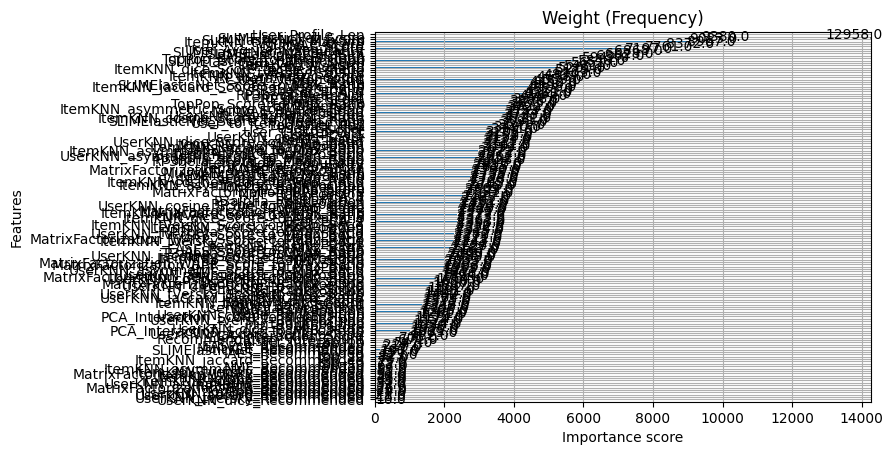

In [10]:
plot_importance(XGBoost_models[0], importance_type='weight', title='Weight (Frequency)')

<Axes: title={'center': 'Gain'}, xlabel='Importance score', ylabel='Features'>

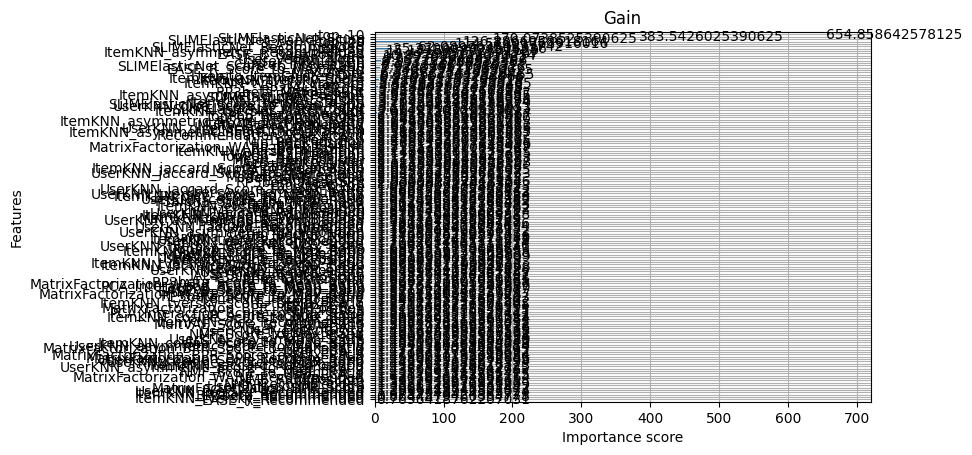

In [11]:
plot_importance(XGBoost_models[0], importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='Importance score', ylabel='Features'>

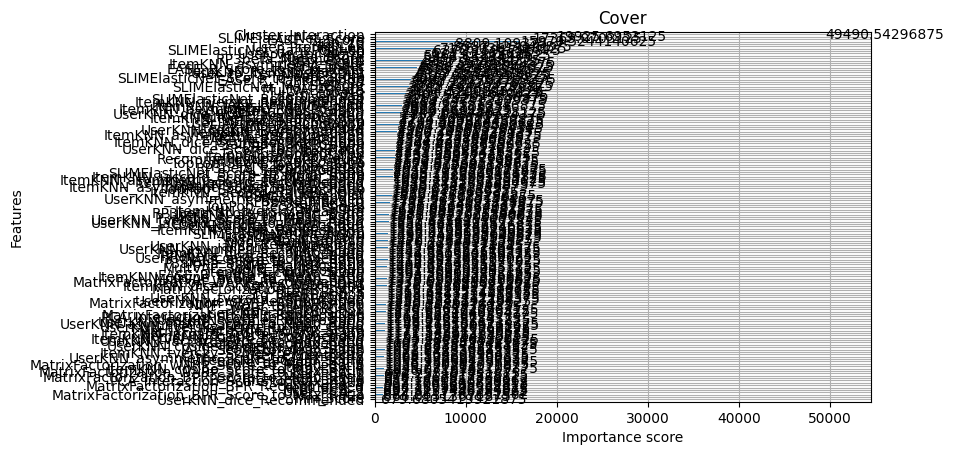

In [12]:
plot_importance(XGBoost_models[0], importance_type='cover', title='Cover')